In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/MyDrive/Master/AINC/Project/Unifews")

Mounted at /content/drive


In [4]:
!pip install torch_geometric ogb eigency ptflops dotmap powerlaw  -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 25.3 MB/s eta 0:00:00


In [10]:
!python run_fb.py -f 42 -c cora -v 0

Option saved.
Config path: ./save/cora/gcn_thr/42-5.0e-01-5.0e-01/config.json
Option dict: {'data': 'cora', 'path': './data/', 'algo': 'gcn_thr', 'epochs': 200, 'patience': 20, 'lr': 0.001, 'weight_decay': 1e-05, 'layer': 2, 'hidden': 512, 'dropout': 0.5, 'thr_a': 0.5, 'thr_w': 0.5, 'inductive': False, 'multil': False, 'seed': 42, 'dev': 0, 'config': 'cora', 'suffix': ''}

n=2485, m=12623, F=1433, C=7 | feat: (2485, 1433), label: (2485,) | 1242/621/622=0.50/0.25/0.25
GNNThr gcn_thr 0.5 0.5
GNNThr(
  (dropout): Dropout(p=0.5, inplace=False)
  (act): ReLU()
  (convs): ModuleList(
    (0): GCNConvThr(1433, 512)
    (1): GCNConvThr(512, 7)
  )
  (norms): ModuleList(
    (0): BatchNorm1d(512, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
  )
)
Epoch:0001 | train loss:2.0186, val acc:0.5443, time:0.4234, macs:1.1526
Epoch:0002 | train loss:1.4088, val acc:0.7488, time:0.4330, macs:2.2890
Epoch:0003 | train loss:1.0487, val acc:0.8196, time:0.4448, macs:3.4128
Epoch:0004 | t

In [9]:
!python run_ablation.py \
  --config cora \
  --algo gcn_thr \
  --dev 0 \
  --thr_mode fixed \
  --thr_a_list 0.5 \
  --thr_w_list 0.5 \
  --pair_mode cartesian \
  --seed_list 42 \
  --result_file save/cora/gcn_thr/ablation_cs_adaptive.json

=== Ablation Start ===
algo=gcn_thr, mode=fixed, data=cora
grid=[(0.5, 0.5)], seeds=[42]

[RUN] seed=42 thr_a=5.000e-01 thr_w=5.000e-01 mode=fixed
n=2485, m=12623, F=1433, C=7 | feat: (2485, 1433), label: (2485,) | 1242/621/622=0.50/0.25/0.25
Epoch:0001 | train loss:1.9465, val acc:0.2866, time:0.4221, macs:0.0070
Epoch:0002 | train loss:1.9455, val acc:0.2915, time:0.4314, macs:0.0121
Epoch:0003 | train loss:1.9452, val acc:0.2915, time:0.4406, macs:0.0172
Epoch:0004 | train loss:1.9448, val acc:0.2915, time:0.4497, macs:0.0223
Epoch:0005 | train loss:1.9445, val acc:0.2915, time:0.4588, macs:0.0273
Epoch:0006 | train loss:1.9441, val acc:0.2915, time:0.4684, macs:0.0324
Epoch:0007 | train loss:1.9437, val acc:0.2915, time:0.4796, macs:0.0375
Epoch:0008 | train loss:1.9434, val acc:0.2915, time:0.4888, macs:0.0426
Epoch:0009 | train loss:1.9430, val acc:0.2915, time:0.4971, macs:0.0477
Epoch:0010 | train loss:1.9427, val acc:0.2915, time:0.5057, macs:0.0528
Epoch:0011 | train loss:1.9

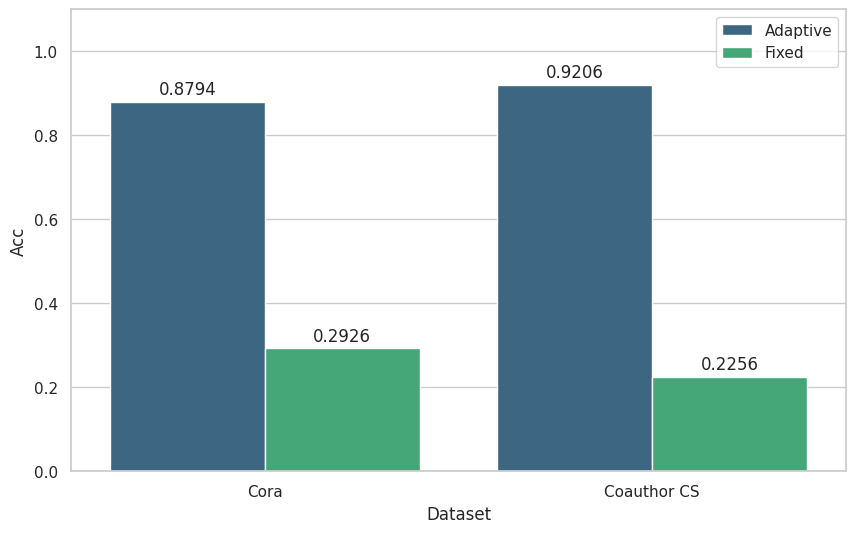

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data from user input
data = [
    {'Dataset': 'Cora', 'Type': 'Adaptive', 'Acc': 0.87942, 'Ttrain': 2.6585, 'Ctrain': 193.418, 'Ttest': 0.0073, 'CTest': 1.0577},
    {'Dataset': 'Cora', 'Type': 'Fixed', 'Acc': 0.29260, 'Ttrain': 2.1762, 'Ctrain': 1.021, 'Ttest': 0.0056, 'CTest': 0.0051},
    {'Dataset': 'Coauthor CS', 'Type': 'Adaptive', 'Acc': 0.92059, 'Ttrain': 10.8093, 'Ctrain': 6003.516, 'Ttest': 0.0939, 'CTest': 29.9684},
    {'Dataset': 'Coauthor CS', 'Type': 'Fixed', 'Acc': 0.22557, 'Ttrain': 9.0032, 'Ctrain': 11.254, 'Ttest': 0.0622, 'CTest': 0.1018}
]
df = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid')
ax = sns.barplot(x='Dataset', y='Acc', hue='Type', data=df, palette='viridis')

# Remove 'Type' from legend title
plt.legend(title='')

# Fix for the '0.000' labels
for p in ax.patches:
    val = p.get_height()
    if val > 0:
        ax.annotate(format(val, '.4f'),
                   (p.get_x() + p.get_width() / 2., val),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.ylim(0, 1.1)
plt.show()

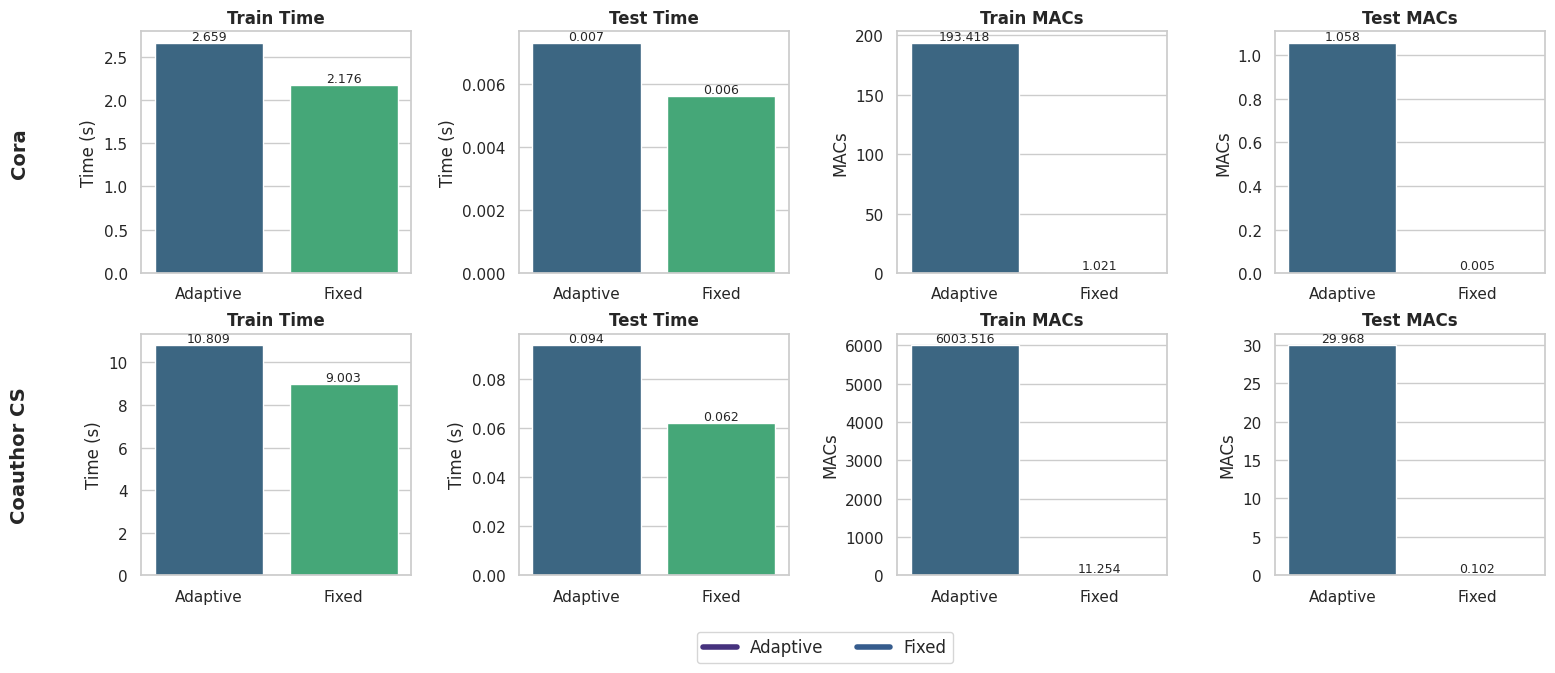

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

metrics = ['Ttrain', 'Ttest', 'Ctrain', 'CTest']
metric_titles = ['Train Time', 'Test Time', 'Train MACs', 'Test MACs']
datasets = ['Cora', 'Coauthor CS']

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=False)
# hspace reduced from 0.4 to 0.25 to bring rows closer
# bottom increased from 0.15 to 0.2 to bring legend closer
plt.subplots_adjust(hspace=0.25, wspace=0.4, left=0.12, bottom=0.2)

for i, ds in enumerate(datasets):
    ds_df = df[df['Dataset'] == ds]
    for j, metric in enumerate(metrics):
        ax = axes[i, j]
        sns.barplot(x='Type', y=metric, data=ds_df, ax=ax, palette='viridis', hue='Type', legend=False)

        ax.set_title(metric_titles[j], fontsize=12, fontweight='bold')
        ax.set_xlabel('')

        if 'Time' in metric_titles[j]:
            ax.set_ylabel('Time (s)')
        else:
            ax.set_ylabel('MACs')

        if j == 0:
            # xy changed from -0.6 to -0.45 to bring dataset text closer to the plot
            ax.annotate(ds, xy=(-0.45, 0.5), xycoords='axes fraction',
                        ha='center', va='center', fontsize=14,
                        fontweight='bold', rotation=90)

        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f'{height:.3f}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=9)

# Shared legend positioned closer using bbox_to_anchor
custom_lines = [Line2D([0], [0], color=sns.color_palette("viridis")[0], lw=4),
                Line2D([0], [0], color=sns.color_palette("viridis")[1], lw=4)]
fig.legend(custom_lines, ['Adaptive', 'Fixed'], loc='lower center',
           bbox_to_anchor=(0.5, 0.08), ncol=2, fontsize=12, frameon=True)

plt.show()

### Comparative Table for Adaptive vs. Fixed Threshold Models

| Threshold Type   | Data   | Model   |     Acc |   Train time (s) |   Train MACs |   Test time (s) |   Test MACs |   NumelA |   NumelW |
|:-----------------|:-------|:--------|--------:|-----------------:|-------------:|----------------:|------------:|---------:|---------:|
| Adaptive         | cora   | gcn_thr | 0.87942 |           3.3417 |      193.418 |          0.0066 |      1.0577 |   19.749 |  417.621 |
| Fixed            | cora   | gcn_thr | 0.2926  |           2.533  |        1.021 |          0.0072 |      0.0051 |    4.97  |    0.005 |


/tmp/ipykernel_944/2211561718.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Threshold Type', y=metric_col, data=df_comparison, palette='viridis')
/tmp/ipykernel_944/2211561718.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Threshold Type', y=metric_col, data=df_comparison, palette='viridis')
/tmp/ipykernel_944/2211561718.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Threshold Type', y=metric_col, data=df_comparison, palette='viridis')
/tmp/ipykernel_944/2211561718.py:83: FutureWarning: 

Passing `palette` without

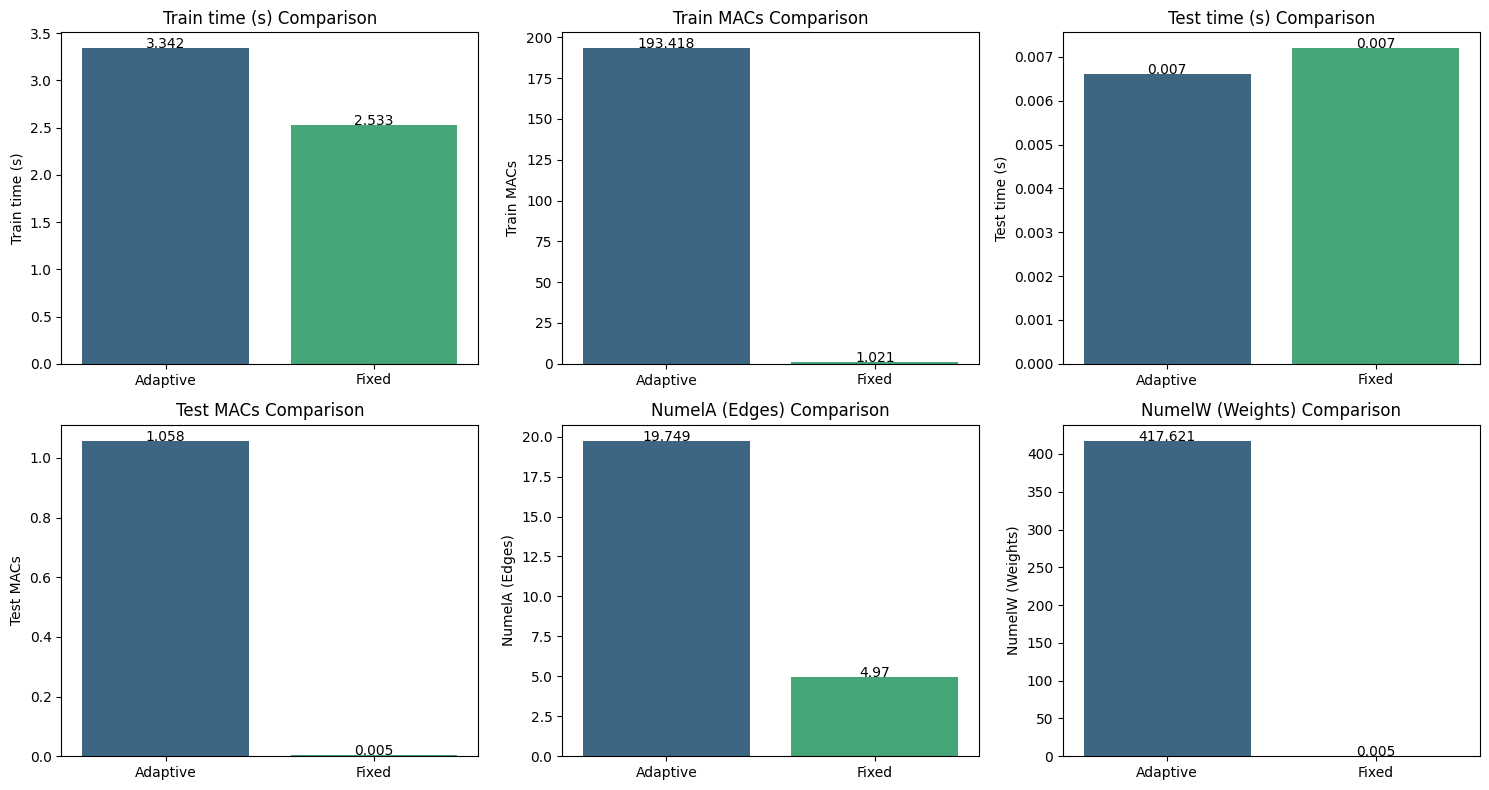

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data for Adaptive Threshold (updated with the new cora run)
adaptive_data = {
    'Data': 'cora',
    'Model': 'gcn_thr',
    'Seed': 42,
    'ThA': 0.5,
    'ThW': 0.5,
    'Acc': 0.87942,
    'Cn': 9,
    'EP': 200,
    'Ttrain': 3.3417,
    'Ctrain': 193.418,
    'Ttest': 0.0066,
    'CTest': 1.0577,
    'NumelA': 19.749,
    'NumelW': 417.621
}

# Data for Fixed Threshold (updated with user's new data)
fixed_data = {
    'Data': 'cora',
    'Model': 'gcn_thr',
    'Seed': 42,
    'ThA': 0.5,
    'ThW': 0.5,
    'Acc': 0.29260,
    'Cn': 1,
    'EP': 200,
    'Ttrain': 2.533,
    'Ctrain': 1.021,
    'Ttest': 0.0072,
    'CTest': 0.0051,
    'NumelA': 4.97,
    'NumelW': 0.005
}

# Create DataFrames
df_adaptive = pd.DataFrame([adaptive_data])
df_fixed = pd.DataFrame([fixed_data])

# Add a 'Threshold Type' column for differentiation
df_adaptive['Threshold Type'] = 'Adaptive'
df_fixed['Threshold Type'] = 'Fixed'

# Combine DataFrames for comparison
df_comparison = pd.concat([df_adaptive, df_fixed], ignore_index=True)

# Rename columns as requested
df_comparison = df_comparison.rename(columns={
    'Ttrain': 'Train time (s)',
    'Ctrain': 'Train MACs',
    'Ttest': 'Test time (s)',
    'CTest': 'Test MACs'
})

print("### Comparative Table for Adaptive vs. Fixed Threshold Models\n")
# Select and display relevant columns for comparison, now including 'Acc'
comparison_cols = ['Threshold Type', 'Data', 'Model', 'Acc', 'Train time (s)', 'Train MACs', 'Test time (s)', 'Test MACs', 'NumelA', 'NumelW']
print(df_comparison[comparison_cols].to_markdown(index=False))

# Metrics to plot with new names, excluding 'Acc'
metrics_to_plot = {
    'Train time (s)': 'Train time (s)',
    'Train MACs': 'Train MACs',
    'Test time (s)': 'Test time (s)',
    'Test MACs': 'Test MACs',
    'NumelA': 'NumelA (Edges)',
    'NumelW': 'NumelW (Weights)'
}

plt.figure(figsize=(15, 8)) # Adjusted figure size
num_metrics = len(metrics_to_plot)
# Calculate optimal subplot grid (e.g., 2 rows, ceil(num_metrics/2) columns)
num_rows = 2
num_cols = (num_metrics + num_rows - 1) // num_rows

for i, (metric_col, metric_label) in enumerate(metrics_to_plot.items()):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.barplot(x='Threshold Type', y=metric_col, data=df_comparison, palette='viridis')
    plt.title(f'{metric_label} Comparison')
    plt.ylabel(metric_label)
    plt.xlabel('')
    # Add values on top of bars for clarity
    for index, row in df_comparison.iterrows():
        plt.text(index, row[metric_col], round(row[metric_col], 3), color='black', ha="center")

plt.tight_layout()
# plt.suptitle('Comparison of Key Metrics: Adaptive vs. Fixed Threshold (Excluding Accuracy)', y=1.02, fontsize=16)
plt.show()

/tmp/ipykernel_944/3472924324.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Threshold Type', y='Acc', data=df_comparison, palette='viridis')


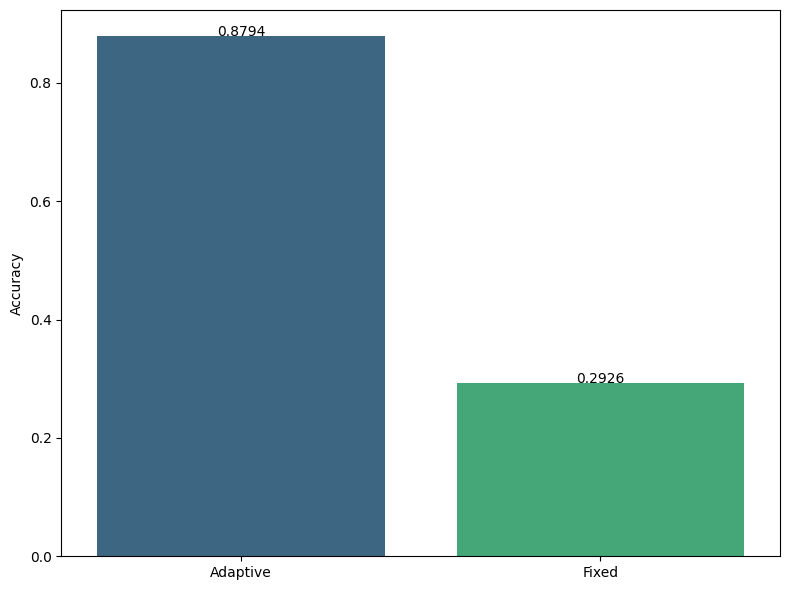

In [2]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Threshold Type', y='Acc', data=df_comparison, palette='viridis')
# plt.title('Accuracy Comparison: Adaptive vs. Fixed Threshold')
plt.ylabel('Accuracy')
plt.xlabel('')
for index, row in df_comparison.iterrows():
    plt.text(index, row['Acc'], round(row['Acc'], 4), color='black', ha="center")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data for Adaptive Threshold (updated with the new cora run)
adaptive_data = {
    'Data': 'cora',
    'Model': 'gcn_thr',
    'Seed': 42,
    'ThA': 0.5,
    'ThW': 0.5,
    'Acc': 0.87942,
    'Cn': 9,
    'EP': 200,
    'Ttrain': 3.3417,
    'Ctrain': 193.418,
    'Ttest': 0.0066,
    'CTest': 1.0577,
    'NumelA': 19.749,
    'NumelW': 417.621
}

# Data for Fixed Threshold (updated with user's new data)
fixed_data = {
    'Data': 'cora',
    'Model': 'gcn_thr',
    'Seed': 42,
    'ThA': 0.5,
    'ThW': 0.5,
    'Acc': 0.29260,
    'Cn': 1,
    'EP': 200,
    'Ttrain': 2.533,
    'Ctrain': 1.021,
    'Ttest': 0.0072,
    'CTest': 0.0051,
    'NumelA': 4.97,
    'NumelW': 0.005
}

# Create DataFrames
df_adaptive = pd.DataFrame([adaptive_data])
df_fixed = pd.DataFrame([fixed_data])

# Add a 'Threshold Type' column for differentiation
df_adaptive['Threshold Type'] = 'Adaptive'
df_fixed['Threshold Type'] = 'Fixed'

# Combine DataFrames for comparison
df_comparison = pd.concat([df_adaptive, df_fixed], ignore_index=True)

# Rename columns as requested
df_comparison = df_comparison.rename(columns={
    'Ttrain': 'Train time (s)',
    'Ctrain': 'Train MACs',
    'Ttest': 'Test time (s)',
    'CTest': 'Test MACs'
})

print("### Comparative Table for Adaptive vs. Fixed Threshold Models\n")
# Select and display relevant columns for comparison, now including 'Acc'
comparison_cols = ['Threshold Type', 'Data', 'Model', 'Acc', 'Train time (s)', 'Train MACs', 'Test time (s)', 'Test MACs', 'NumelA', 'NumelW']
print(df_comparison[comparison_cols].to_markdown(index=False))

# Metrics to plot with new names, excluding 'Acc'
metrics_to_plot = {
    'Train time (s)': 'Train time (s)',
    'Train MACs': 'Train MACs',
    'Test time (s)': 'Test time (s)',
    'Test MACs': 'Test MACs',
    'NumelA': 'NumelA (Edges)',
    'NumelW': 'NumelW (Weights)'
}

plt.figure(figsize=(15, 8)) # Adjusted figure size
num_metrics = len(metrics_to_plot)
# Calculate optimal subplot grid (e.g., 2 rows, ceil(num_metrics/2) columns)
num_rows = 2
num_cols = (num_metrics + num_rows - 1) // num_rows

for i, (metric_col, metric_label) in enumerate(metrics_to_plot.items()):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.barplot(x='Threshold Type', y=metric_col, data=df_comparison, palette='viridis')
    plt.title(f'{metric_label} Comparison')
    plt.ylabel(metric_label)
    plt.xlabel('')
    # Add values on top of bars for clarity
    for index, row in df_comparison.iterrows():
        plt.text(index, row[metric_col], round(row[metric_col], 3), color='black', ha="center")

plt.tight_layout()
# plt.suptitle('Comparison of Key Metrics: Adaptive vs. Fixed Threshold (Excluding Accuracy)', y=1.02, fontsize=16)
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Threshold Type', y='Acc', data=df_comparison, palette='viridis')
# plt.title('Accuracy Comparison: Adaptive vs. Fixed Threshold')
plt.ylabel('Accuracy')
plt.xlabel('')
for index, row in df_comparison.iterrows():
    plt.text(index, row['Acc'], round(row['Acc'], 4), color='black', ha="center")
plt.tight_layout()
plt.show()